# EDA Representative Sample Visualization

Visualize representative samples from every dataset with completed EDA outputs under `analysis/eda/<dataset>/sample_stats.csv`.

The selection emphasizes:

- different target classes first
- different target sizes within each class: small, median, and large target area fraction
- low target-area / bbox-area coverage
- different target instances, using connected components larger than 10 pixels so one-pixel mask specks do not dominate

Each panel shows the image, target mask overlay, bbox, and key sample statistics. For multi-target datasets such as CAMUS, selected source frames show all available target classes together.


In [1]:
from __future__ import annotations

from pathlib import Path
import argparse
import csv
import math
import sys
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from skimage import measure

ROOT = Path.cwd()
if not (ROOT / 'datasets').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from datasets.common import bboxes_from_mask, ensure_three_channels, normalize_to_uint8
from datasets.loader import add_dataset_args, build_decoder_from_args, default_dataset_root
from datasets.registry import DATASET_REGISTRY

EDA_ROOT = ROOT / 'analysis' / 'eda'
AVAILABLE_DATASETS = sorted(
    path.parent.name for path in EDA_ROOT.glob('*/sample_stats.csv')
)
AVAILABLE_DATASETS

['aulid',
 'blusg',
 'busbra',
 'busi',
 'camus',
 'oku',
 'roblus',
 'tnsc2020',
 'ultrabones100k',
 'uns']

## Load EDA Statistics

In [2]:
def read_stats(dataset: str) -> list[dict[str, str]]:
    path = EDA_ROOT / dataset / 'sample_stats.csv'
    with path.open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))

def as_float(row: dict[str, str], key: str, default: float = math.nan) -> float:
    try:
        value = float(row.get(key, ''))
    except (TypeError, ValueError):
        return default
    return value if math.isfinite(value) else default

stats_by_dataset = {dataset: read_stats(dataset) for dataset in AVAILABLE_DATASETS}
for dataset, rows in stats_by_dataset.items():
    print(f'{dataset:16s} {len(rows):7d} samples')

aulid                635 samples
blusg                252 samples
busbra              1875 samples
busi                 647 samples
camus               4000 samples
oku                 1608 samples
roblus               764 samples
tnsc2020            3644 samples
ultrabones100k    101343 samples
uns                 5635 samples


## Select Representative Samples

In [3]:
def row_with_min(rows: list[dict[str, str]], key: str, positive: bool = False):
    candidates = [row for row in rows if math.isfinite(as_float(row, key))]
    if positive:
        candidates = [row for row in candidates if as_float(row, key) > 0]
    return min(candidates, key=lambda row: as_float(row, key)) if candidates else None

def row_with_max(rows: list[dict[str, str]], key: str):
    candidates = [row for row in rows if math.isfinite(as_float(row, key))]
    return max(candidates, key=lambda row: as_float(row, key)) if candidates else None

def row_nearest_median(rows: list[dict[str, str]], key: str):
    candidates = [row for row in rows if math.isfinite(as_float(row, key))]
    if not candidates:
        return None
    values = np.array([as_float(row, key) for row in candidates], dtype=float)
    median = float(np.median(values))
    return min(candidates, key=lambda row: abs(as_float(row, key) - median))

def target_label(row: dict[str, str]) -> str:
    return row.get('target_label') or row.get('target_class_name') or 'target'

def source_sample_key(row: dict[str, str]) -> str:
    sample_id = row['sample_id']
    return sample_id.split('__', maxsplit=1)[0]

def target_labels_in(rows: list[dict[str, str]]) -> list[str]:
    return sorted({target_label(row) for row in rows if target_label(row)})

def representatives_for_dataset(dataset: str, rows: list[dict[str, str]]):
    choices = []

    # Class and size coverage: small / median / large within each class.
    for label in target_labels_in(rows):
        label_rows = [row for row in rows if target_label(row) == label]
        choices.extend([
            (f'small {label}', row_with_min(label_rows, 'target_area_fraction', positive=True)),
            (f'median {label}', row_nearest_median(label_rows, 'target_area_fraction')),
            (f'large {label}', row_with_max(label_rows, 'target_area_fraction')),
        ])

    # Shape / prompt quality coverage.
    choices.extend([
        ('lowest target/bbox', row_with_min(rows, 'target_bbox_area_ratio', positive=True)),
        ('raw most components', row_with_max(rows, 'component_count')),
    ])

    seen = set()
    reps = []
    for reason, row in choices:
        if row is None:
            continue
        dedupe_key = (source_sample_key(row), target_label(row), reason.split()[0])
        if dedupe_key in seen:
            continue
        seen.add(dedupe_key)
        reps.append((reason, row))
    return reps

representatives = {
    dataset: representatives_for_dataset(dataset, rows)
    for dataset, rows in stats_by_dataset.items()
}

for dataset, reps in representatives.items():
    print('' + dataset)
    for reason, row in reps:
        print(
            f"  {reason:22s} {row['sample_id']:40s} "
            f"label={target_label(row):10s} "
            f"area={as_float(row, 'target_area_fraction'):.4f} "
            f"target/bbox={as_float(row, 'target_bbox_area_ratio'):.4f} "
            f"raw_components={as_float(row, 'component_count'):.0f}"
        )


aulid
  small liver mass       Benign/171                               label=liver mass area=0.0003 target/bbox=0.6019 raw_components=1
  median liver mass      Malignant/316                            label=liver mass area=0.0204 target/bbox=0.7841 raw_components=1
  large liver mass       Malignant/247                            label=liver mass area=0.2925 target/bbox=0.6684 raw_components=1
  lowest target/bbox     Malignant/329                            label=liver mass area=0.0188 target/bbox=0.5215 raw_components=1
  raw most components    Malignant/73                             label=liver mass area=0.0768 target/bbox=0.6882 raw_components=2
blusg
  small breast tumor     case181                                  label=breast tumor area=0.0058 target/bbox=0.7173 raw_components=1
  median breast tumor    case156                                  label=breast tumor area=0.0505 target/bbox=0.6658 raw_components=1
  large breast tumor     case038                                  l

## Decoder Helpers

The notebook uses the same registry-backed loader as the benchmark and EDA script. It searches only until the selected sample IDs are found, so large datasets are not loaded into memory all at once.

In [4]:
def parser_for_dataset_args() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser()
    add_dataset_args(parser)
    return parser

def decoder_for_dataset(dataset: str):
    parser = parser_for_dataset_args()
    args = parser.parse_args([
        '--dataset', dataset,
        '--dataset-root', str(ROOT / default_dataset_root(dataset)),
        '--no-auto-download',
    ])
    return build_decoder_from_args(args)

def resolve_sample_id(dataset: str, sample_id: str) -> str:
    rows = stats_by_dataset.get(dataset, [])
    known_ids = {row['sample_id'] for row in rows}
    if sample_id in known_ids:
        return sample_id
    if dataset == 'ultrabones100k':
        matches = [row['sample_id'] for row in rows if row['sample_id'].endswith(f'_{sample_id}')]
        if len(matches) == 1:
            return matches[0]
        if len(matches) > 1:
            raise ValueError(f"UltraBones id '{sample_id}' is ambiguous: {matches[:10]}")
    return sample_id

def find_samples(dataset: str, sample_ids: Iterable[str]):
    wanted = list(dict.fromkeys(resolve_sample_id(dataset, sample_id) for sample_id in sample_ids))
    found = {}
    decoder = decoder_for_dataset(dataset)

    if hasattr(decoder, 'load_sample'):
        for sample_id in wanted:
            try:
                sample = decoder.load_sample(sample_id)
            except KeyError:
                continue
            found[sample.sample_id] = sample

    missing = set(wanted) - set(found)
    if missing:
        for sample in decoder.iter_samples():
            if sample.sample_id in missing:
                found[sample.sample_id] = sample
                missing.remove(sample.sample_id)
                if not missing:
                    break

    if missing:
        print(f'{dataset}: missing samples: {sorted(missing)}')
    return found

## Plot Helpers

In [5]:
LABEL_COLORS = {
    'LV': (1.0, 0.0, 0.0, 0.38),
    'LA': (0.0, 0.45, 1.0, 0.38),
    'MYO': (0.1, 0.7, 0.2, 0.38),
}
FALLBACK_COLORS = [
    (1.0, 0.0, 0.0, 0.38),
    (0.0, 0.45, 1.0, 0.38),
    (0.1, 0.7, 0.2, 0.38),
    (1.0, 0.55, 0.0, 0.38),
    (0.65, 0.25, 0.9, 0.38),
]

MIN_MEANINGFUL_COMPONENT_AREA = 10
BBOX_MODE = 'union'  # set to 'individual' for one bbox per component >15 px

def meaningful_component_areas(mask: np.ndarray, min_area: int = MIN_MEANINGFUL_COMPONENT_AREA) -> list[int]:
    labels = measure.label(np.asarray(mask) > 0, connectivity=1)
    return [int(prop.area) for prop in measure.regionprops(labels) if int(prop.area) > min_area]

def meaningful_component_count(mask: np.ndarray, min_area: int = MIN_MEANINGFUL_COMPONENT_AREA) -> int:
    return len(meaningful_component_areas(mask, min_area=min_area))

def rows_for_source(dataset: str, seed_row: dict[str, str]) -> list[dict[str, str]]:
    rows = stats_by_dataset[dataset]
    if len(target_labels_in(rows)) <= 1:
        return [seed_row]
    source_key = source_sample_key(seed_row)
    source_rows = [row for row in rows if source_sample_key(row) == source_key]
    return sorted(source_rows, key=lambda row: target_label(row))

def color_for_label(label: str, index: int):
    return LABEL_COLORS.get(label, FALLBACK_COLORS[index % len(FALLBACK_COLORS)])

def draw_mask_and_bbox(axis, mask: np.ndarray, color, bbox_color: str):
    mask = (np.asarray(mask) > 0).astype(np.uint8)
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[mask.astype(bool), :] = color
    axis.imshow(overlay)
    bboxes = bboxes_from_mask(mask, min_area=16, mode=BBOX_MODE)
    if bboxes is not None:
        for bbox in bboxes:
            x0, y0, x1, y1 = [int(v) for v in bbox]
            axis.add_patch(
                Rectangle(
                    (x0, y0),
                    max(x1 - x0 + 1, 1),
                    max(y1 - y0 + 1, 1),
                    edgecolor=bbox_color,
                    facecolor=(0, 0, 0, 0),
                    linewidth=1.4,
                )
            )

def meaningful_component_representatives(dataset: str, candidate_count: int = 40, keep: int = 1):
    rows = stats_by_dataset[dataset]
    candidates = sorted(rows, key=lambda row: as_float(row, 'component_count', 0), reverse=True)
    candidates = candidates[:candidate_count]
    samples = find_samples(dataset, [row['sample_id'] for row in candidates])
    scored = []
    for row in candidates:
        sample = samples.get(row['sample_id'])
        if sample is None:
            continue
        areas = meaningful_component_areas(sample.mask)
        scored.append((len(areas), max(areas) if areas else 0, row, areas))
    scored = [item for item in scored if item[0] > 1]
    scored.sort(key=lambda item: (item[0], item[1]), reverse=True)
    return [(f'most cc>{MIN_MEANINGFUL_COMPONENT_AREA}px', item[2]) for item in scored[:keep]]

def plot_target_group(axis, dataset: str, samples: dict, seed_row: dict[str, str], reason: str):
    group_rows = rows_for_source(dataset, seed_row)
    available_rows = [row for row in group_rows if row['sample_id'] in samples]
    if not available_rows:
        axis.axis('off')
        axis.set_title(f"missing\n{seed_row['sample_id']}")
        return

    base_sample = samples[available_rows[0]['sample_id']]
    image = ensure_three_channels(normalize_to_uint8(base_sample.image))
    axis.imshow(image)

    label_parts = []
    cc_parts = []
    for index, row in enumerate(available_rows):
        sample = samples[row['sample_id']]
        label = target_label(row)
        color = color_for_label(label, index)
        bbox_color = '#00FFFF' if index == 0 else '#FFFF00'
        draw_mask_and_bbox(axis, sample.mask, color, bbox_color)
        areas = meaningful_component_areas(sample.mask)
        label_parts.append(label)
        cc_parts.append(f"{label}:cc>{MIN_MEANINGFUL_COMPONENT_AREA}px={len(areas)}")

    axis.axis('off')
    axis.set_title(f"{reason}\n{source_sample_key(seed_row)}", fontsize=8)

def plot_sample(axis, sample, row: dict[str, str], reason: str):
    plot_target_group(axis, row['dataset'], {row['sample_id']: sample}, row, reason)

def plot_dataset_representatives(dataset: str, max_reps: int = 9):
    reps = representatives[dataset][:]

    # Add a meaningful multi-instance example based on components >10 px.
    for extra in meaningful_component_representatives(dataset, candidate_count=40, keep=1):
        if all(extra[1]['sample_id'] != row['sample_id'] for _reason, row in reps):
            reps.append(extra)

    reps = reps[:max_reps]
    grouped_rows = []
    sample_ids = []
    for reason, row in reps:
        rows = rows_for_source(dataset, row)
        grouped_rows.append((reason, row, rows))
        sample_ids.extend(source_row['sample_id'] for source_row in rows)

    samples = find_samples(dataset, sample_ids)
    if not samples:
        return None

    ncols = len(grouped_rows)
    fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.3), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for axis, (reason, row, _rows) in zip(axes, grouped_rows):
        plot_target_group(axis, dataset, samples, row, reason)
    fig.suptitle(f'{dataset.upper()} representative EDA samples', fontsize=12)
    return fig


## Visualize All Datasets

This loops over all datasets with completed EDA statistics. For very large datasets, finding the selected sample IDs may take a little while because the decoder streams from disk.

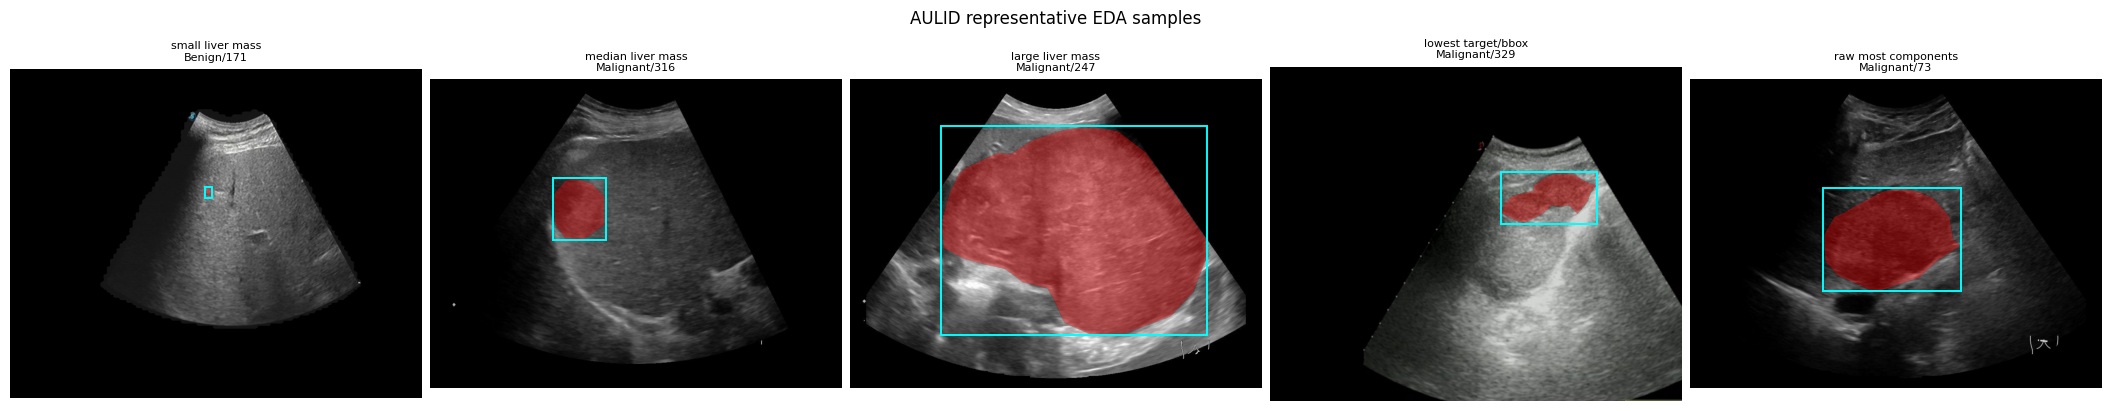

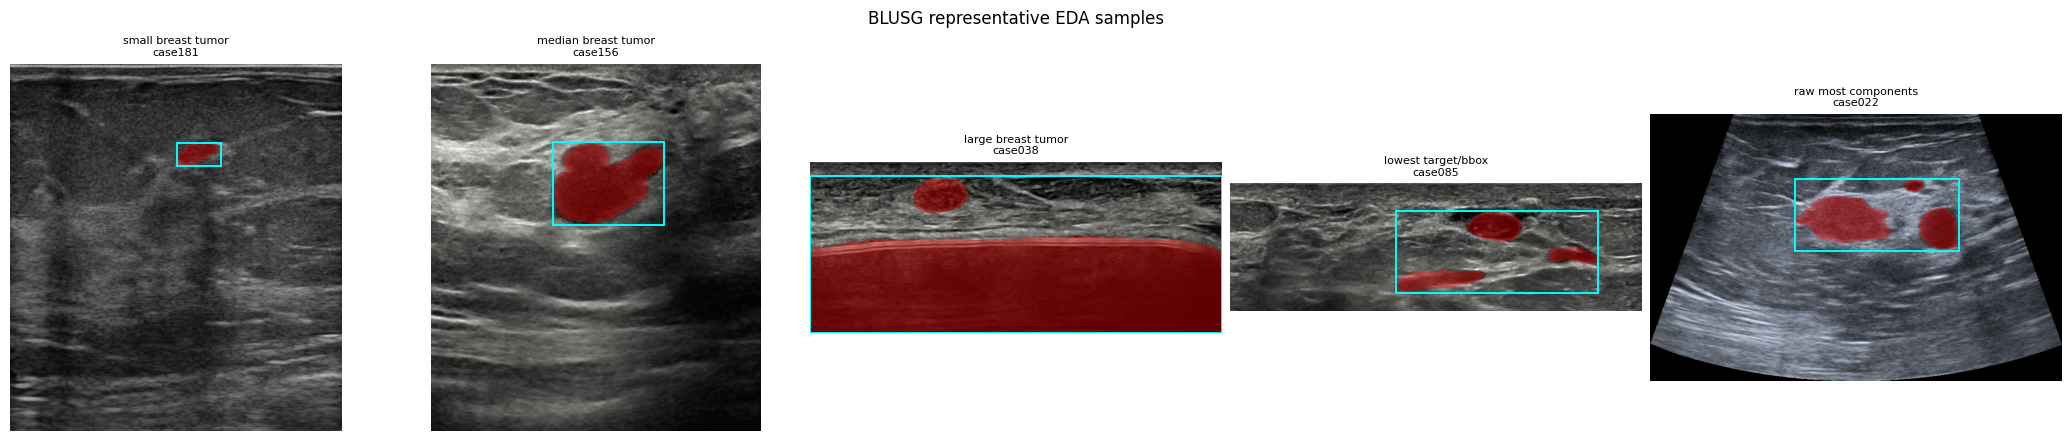

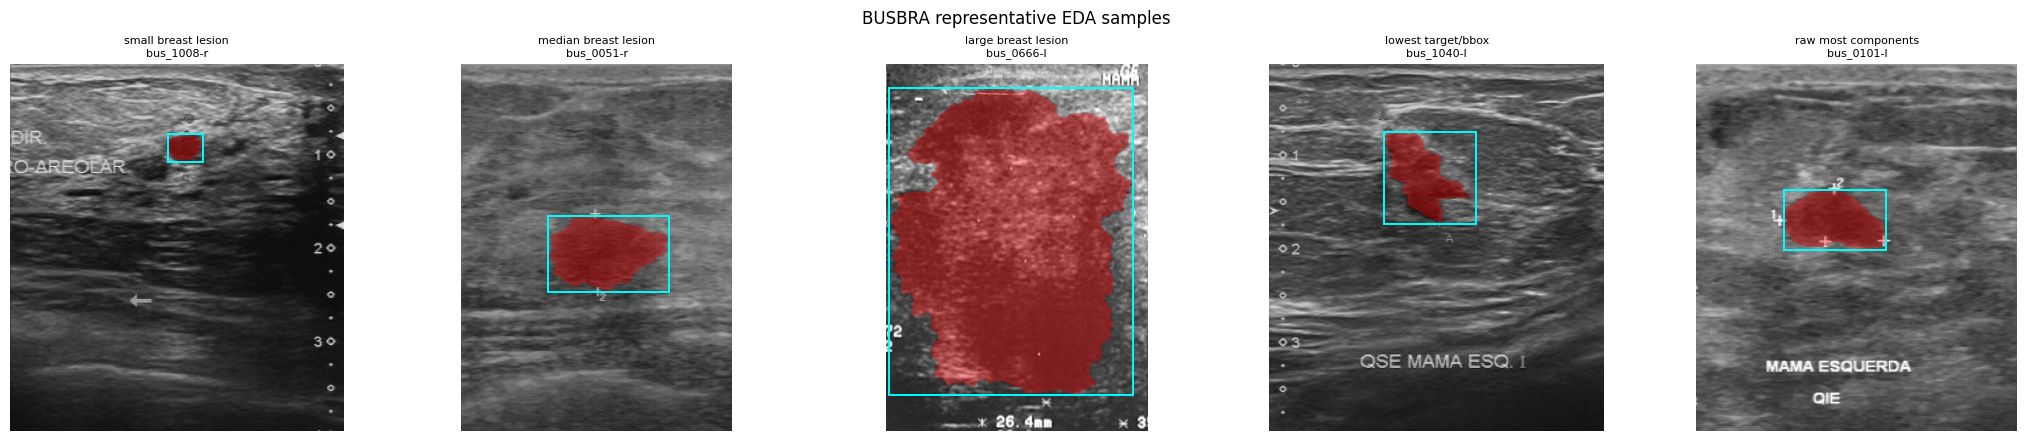

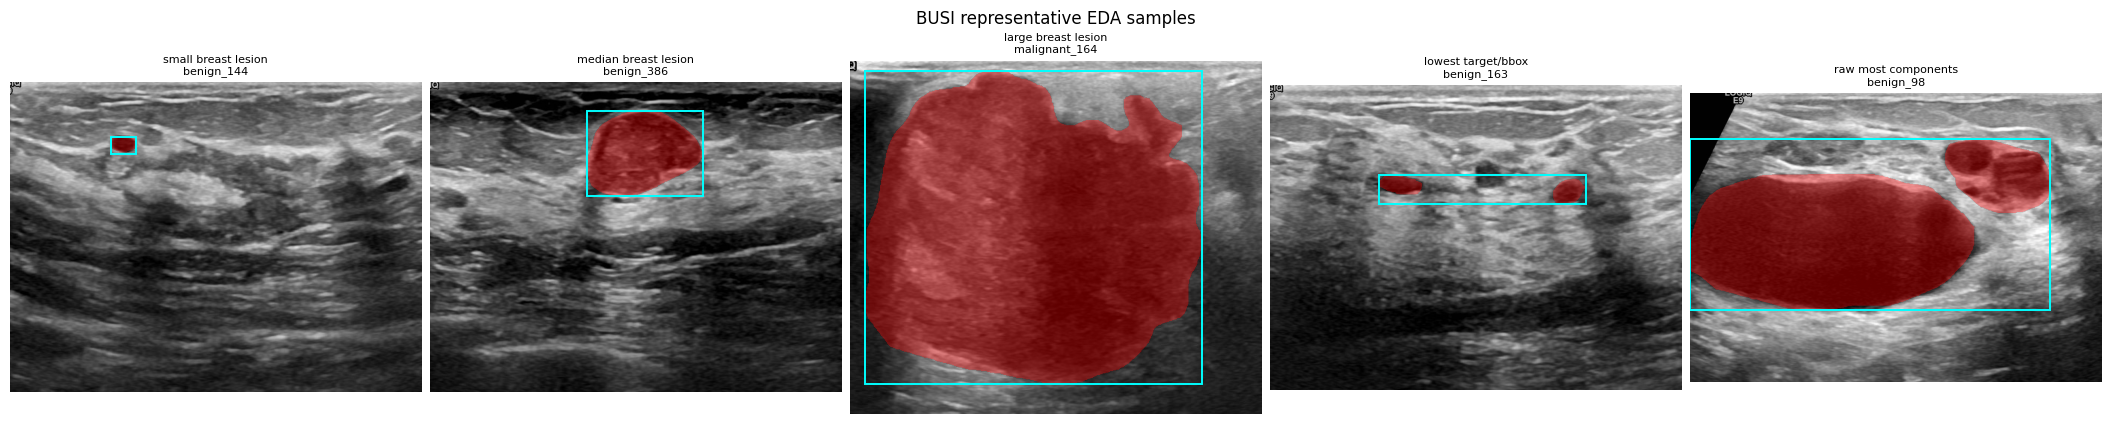

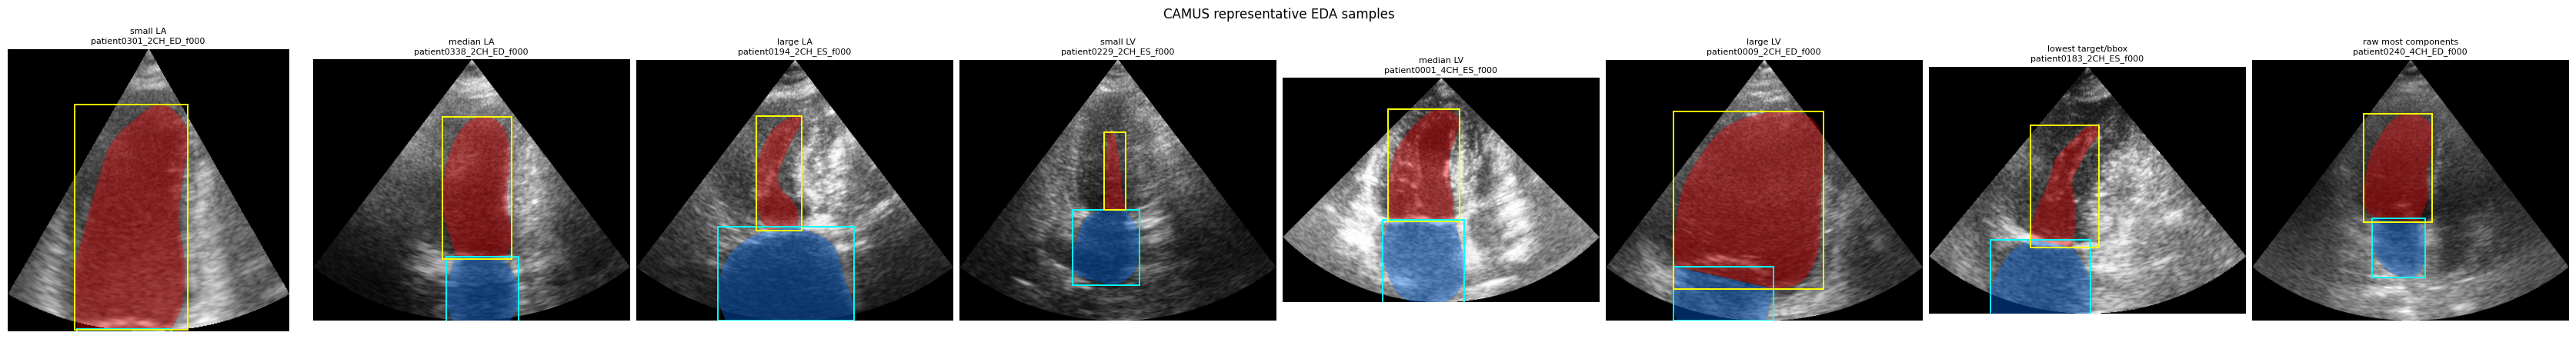

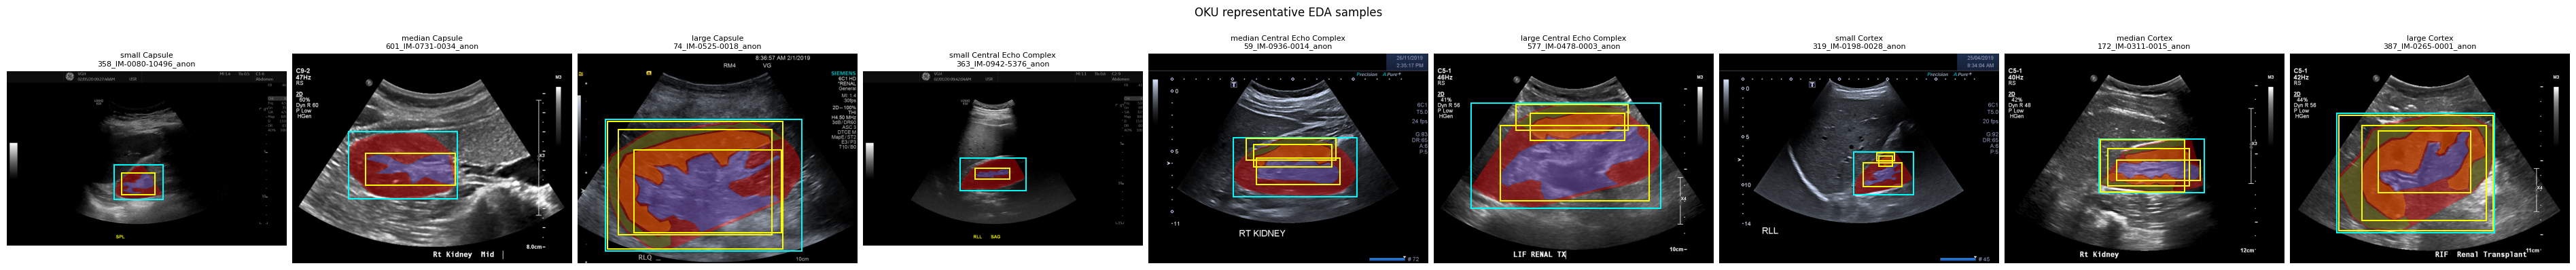

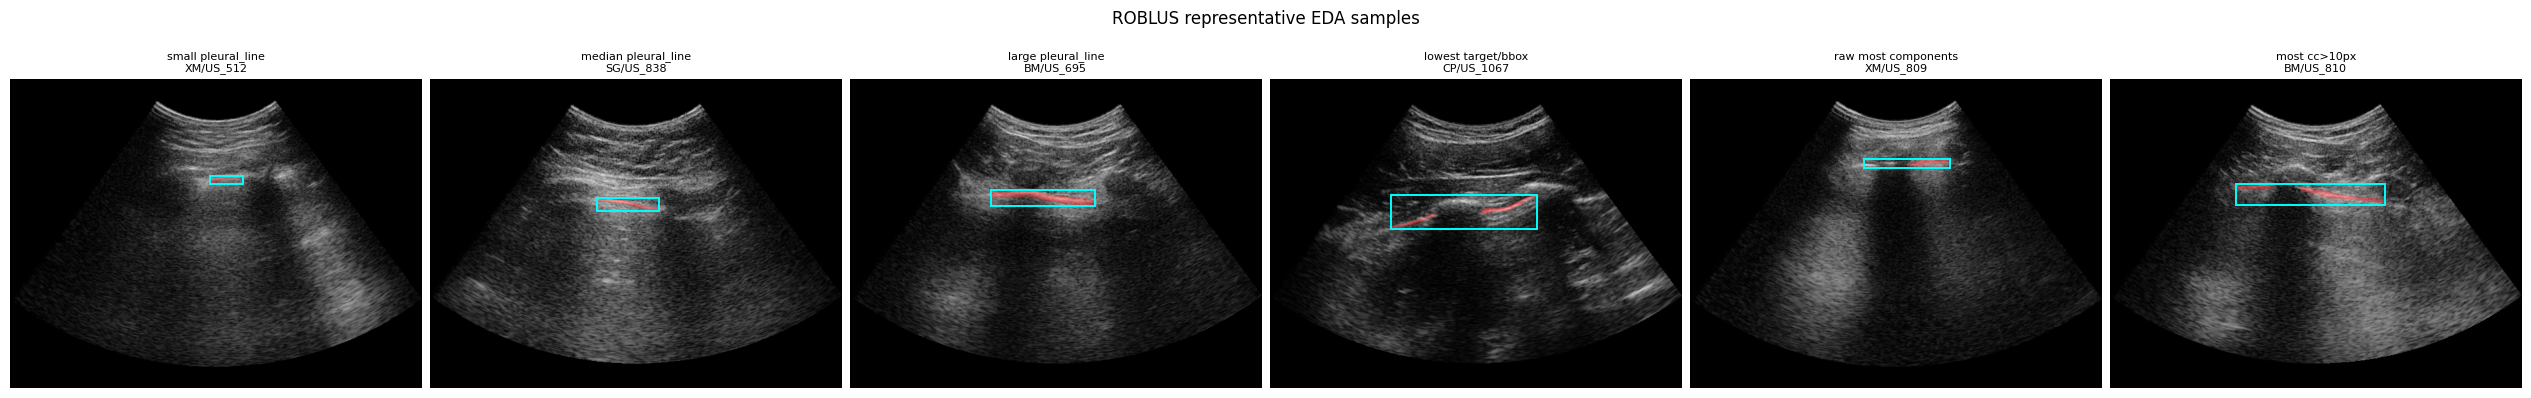

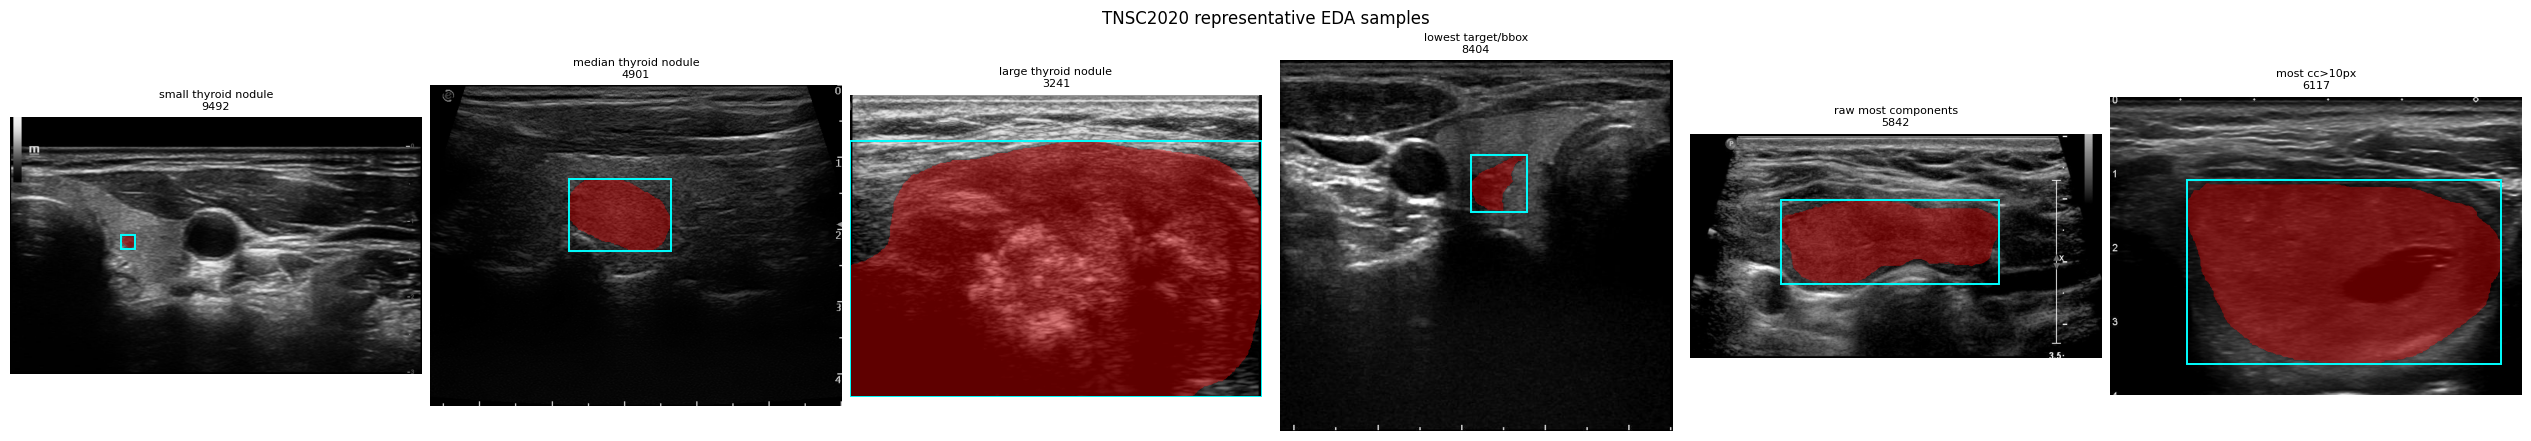

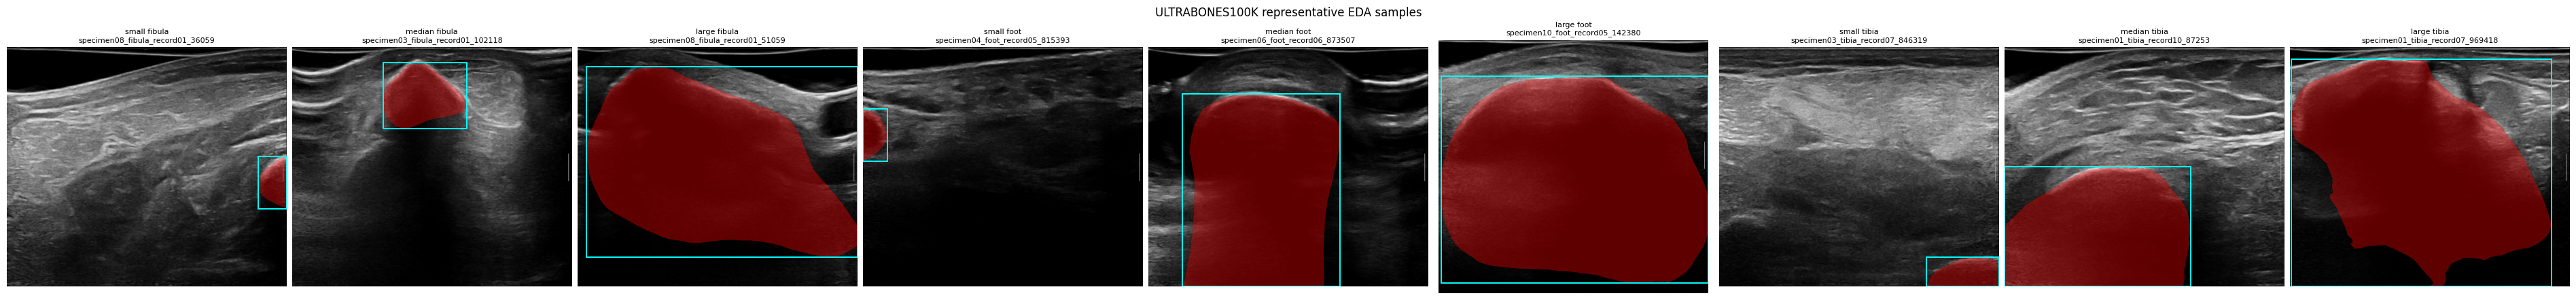

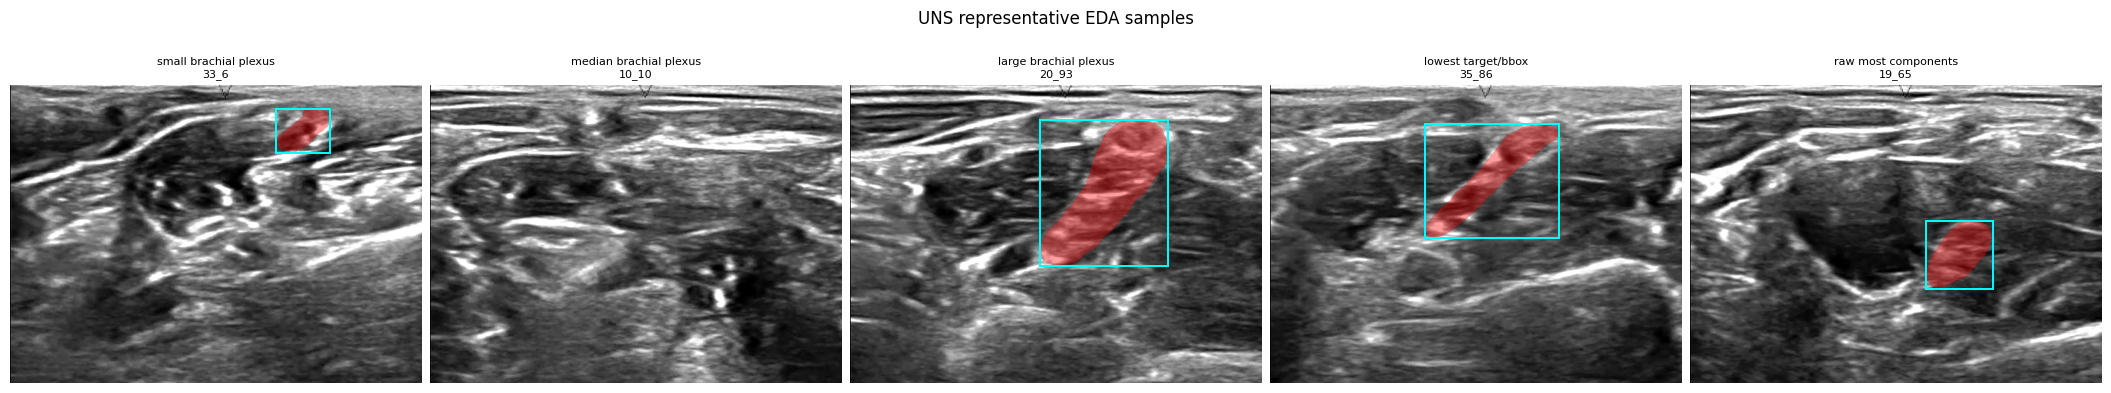

In [6]:
DATASETS_TO_SHOW = AVAILABLE_DATASETS

for dataset in DATASETS_TO_SHOW:
    fig = plot_dataset_representatives(dataset, max_reps=9)
    if fig is not None:
        plt.show()


## Inspect One Dataset

Use these cells for focused review after the all-dataset pass.

Text(0.5, 0.98, 'ULTRABONES100K random EDA samples')

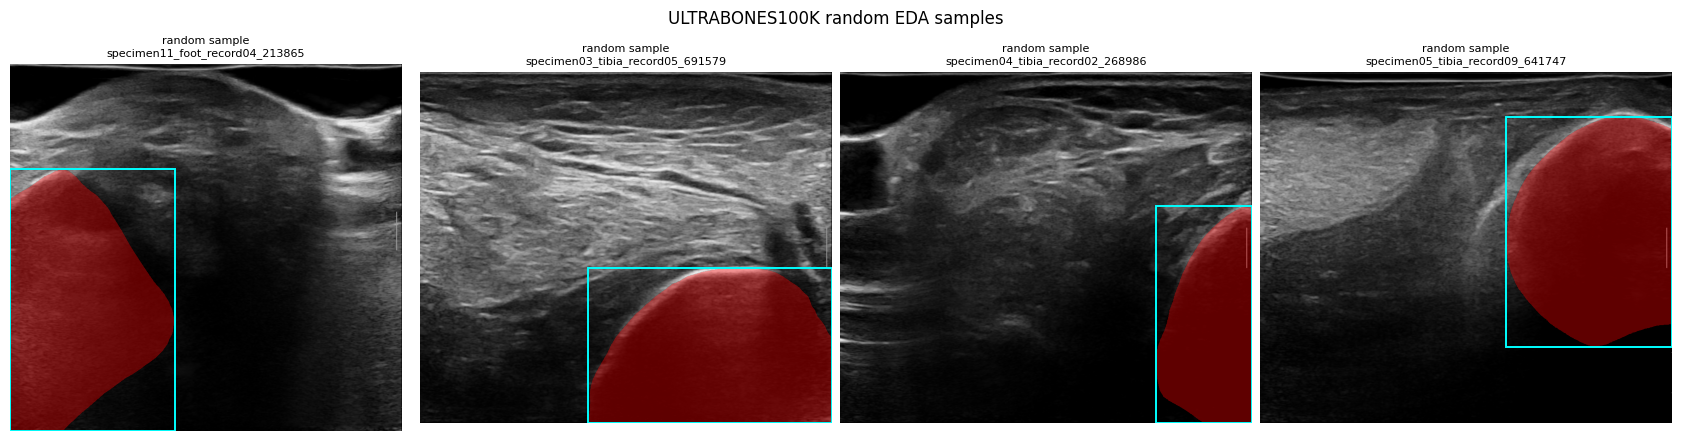

In [7]:
dataset = 'ultrabones100k'
n_samples = 4

def random_dataset_examples(dataset: str, n_samples: int = 4):
    rng = np.random.default_rng()
    rows = stats_by_dataset[dataset]
    selected_rows = rng.choice(rows, size=min(n_samples, len(rows)), replace=False)
    selected_rows = [dict(row) for row in np.atleast_1d(selected_rows)]
    sample_ids = []
    for row in selected_rows:
        sample_ids.extend(source_row['sample_id'] for source_row in rows_for_source(dataset, row))
    samples = find_samples(dataset, sample_ids)
    return selected_rows, samples

selected_rows, samples = random_dataset_examples(dataset, n_samples=n_samples)

fig, axes = plt.subplots(
    1,
    len(selected_rows),
    figsize=(4.2 * len(selected_rows), 4.3),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for axis, row in zip(axes, selected_rows):
    plot_target_group(axis, dataset, samples, row, 'random sample')

fig.suptitle(f'{dataset.upper()} random EDA samples', fontsize=12)


## Inspect a Specific Image

Use these cells for focused review after the all-dataset pass.

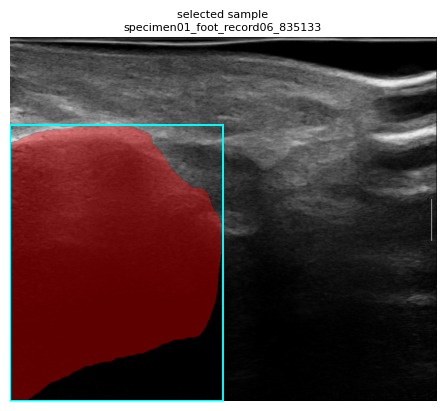

In [8]:
dataset = 'ultrabones100k'
sample_id = 'specimen01_foot_record06_835133'
rows = {row['sample_id']: row for row in stats_by_dataset[dataset]}
sample = find_samples(dataset, [sample_id])[sample_id]
fig, axis = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
plot_target_group(axis, dataset, {sample_id: sample}, rows[sample_id], 'selected sample')
